# Opposite strand


## phase-phase comparison

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
#import astropy.stats.circstats as circstats
from multiprocessing import Pool
from functools import partial
import pycircstat

ModuleNotFoundError: No module named 'imp'

In [3]:
infile_gtf = f'../resources/genome/GRCm38/gene_annotation.gtf'
infile_core_circadian_genes = '../resources/core_circadian_clock_genes.txt'

# get genes
gene_gtf = pd.read_csv(infile_gtf, sep='\t', comment='#', header=None)

# parse gtf and extract atributes
gene_gtf.columns = ['chrom','source','feature','start','end','score','strand','frame','attributes']
attributes = ['gene_id','gene_type','gene_name','transcript_id','transcript_type','transcript_name','level','tag']
# parse the gtf's 9 th column (attributes sep by ;)
for att in attributes:
    if att=='level':
        gene_gtf[att] = gene_gtf['attributes'].str.extract(att + ' (.*?);')
        continue
    else:
        gene_gtf[att] = gene_gtf['attributes'].str.extract(rf'{att} "(.*?)";')
# drop attribute column and set gene_id as index
gene_gtf.drop('attributes', axis=1, inplace=True)
#gene_gtf.set_index('gene_id', inplace=True)


# get circadian genes
core_circadian_genes = pd.read_csv(infile_core_circadian_genes, sep='\t').loc[:,'mm10'].values

In [4]:
bin_size = 1000

# Load kalman filter at chromosome level
infile = f"../results/GRCm38/kalman/extended_kalman_on_chromosomes_bin{bin_size}bp.csv"
kalman = pd.read_csv(infile,sep='\t')


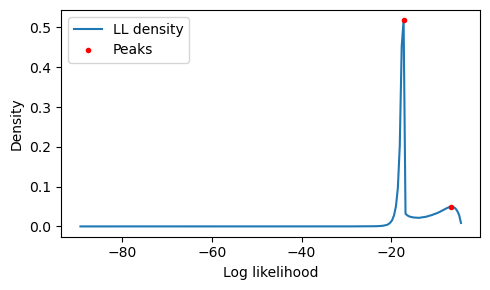

In [5]:
# Plot the log likelihoods distribution
fig, ax = plt.subplots(figsize=(5, 3))
[h,bins] = np.histogram(kalman.LL, bins=200, density=True)
x = 0.5 * (bins[1:] + bins[:-1])  # bin centers
# find local maxima in the histogram
peaks, prop = find_peaks(h, height=0.01)
peaks_x = x[peaks]
peaks_h = prop['peak_heights']
ax.plot(x, h, label='LL density')
ax.plot(peaks_x, peaks_h, 'r.', label='Peaks')
ax.set_xlabel('Log likelihood')
ax.set_ylabel('Density')
ax.legend(loc='upper left')

fig.tight_layout()
fig.savefig(f"fig/fig4/kalman_log_likelihood_distribution_bin{bin_size}bp.pdf")

# clip log likelihoods to the range of the peaks and normalize to [0,1]
kalman['LL_norm'] = np.clip(kalman.LL,peaks_x[0],peaks_x[1])
kalman['LL_norm'] = (kalman['LL_norm'] - peaks_x[0]) / (peaks_x[1] - peaks_x[0])

In [6]:
# split by strand
kalman_plus = kalman[kalman['strand'] == '+']
kalman_minus = kalman[kalman['strand'] == '-']
# inner join on ['chr','start','end'] columns
kalman_innerjoin = pd.merge(kalman_plus, kalman_minus, on=['chr', 'start', 'end'], suffixes=('_p', '_m'))
kalman_innerjoin.loc[:,'mean_amp'] = .5 * (kalman_innerjoin['amp_m'] + kalman_innerjoin['amp_p'])
kalman_innerjoin.loc[:,'mean_norm_LL'] =  .5 * (kalman_innerjoin['LL_norm_p'] + kalman_innerjoin['LL_norm_m'])

print("Whole table:",kalman.shape[0],"\nfwd table:", kalman_plus.shape[0], "\nrev table", kalman_minus.shape[0],"\nInner join:", kalman_innerjoin.shape[0])

Whole table: 1741661 
fwd table: 874447 
rev table 867214 
Inner join: 434919


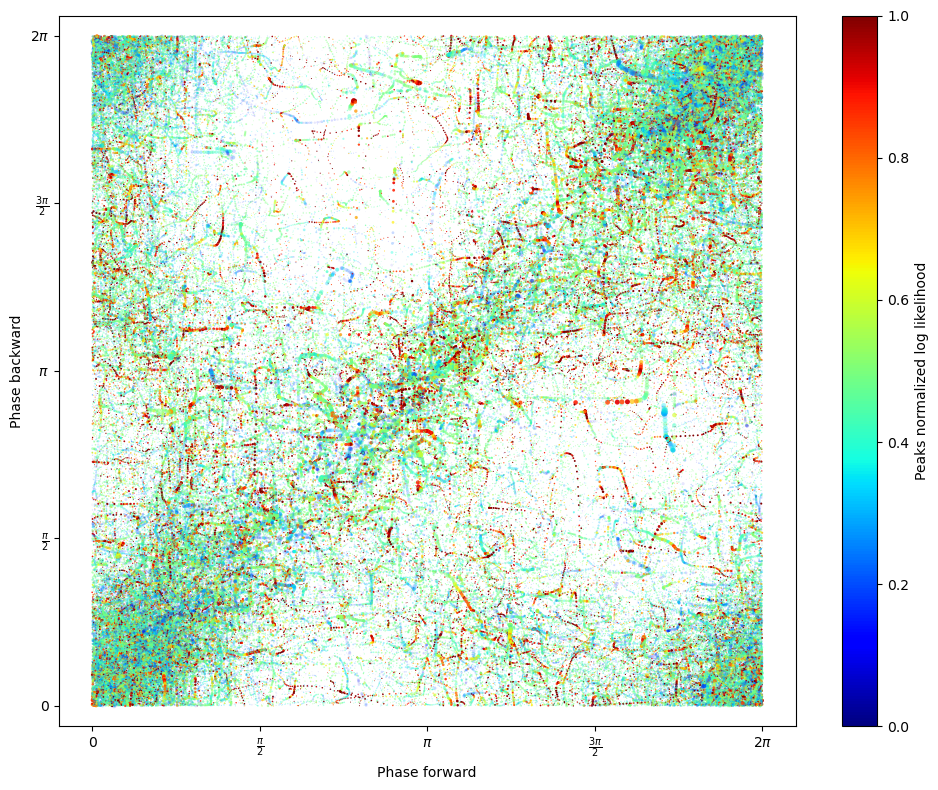

In [8]:
# plot scatter phase (+ strand) vs phase (- strand)
fig, ax = plt.subplots(figsize=(10, 8))

hdl = ax.scatter(kalman_innerjoin['phi_p'], kalman_innerjoin['phi_m'], s=kalman_innerjoin['mean_amp']*10, c=kalman_innerjoin['mean_norm_LL'], alpha = kalman_innerjoin['mean_norm_LL'], cmap='jet', edgecolors='none')
fig.colorbar(hdl, ax=ax, label='Peaks normalized log likelihood')
ax.set_xticks(np.arange(0, 2*np.pi + np.pi/2, np.pi/2))
ax.set_xticklabels(['0', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$'])
ax.set_yticks(np.arange(0, 2*np.pi + np.pi/2, np.pi/2))
ax.set_yticklabels(['0', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$'])
ax.set_xlabel('Phase forward')
ax.set_ylabel('Phase backward')
ax.set_xlim(0, 2*np.pi)
ax.set_ylim(0, 2*np.pi)
ax.axis('equal')

fig.tight_layout()
fig.savefig(f"fig/fig4/kalman_phase_scatter_bin{bin_size}bp.pdf")

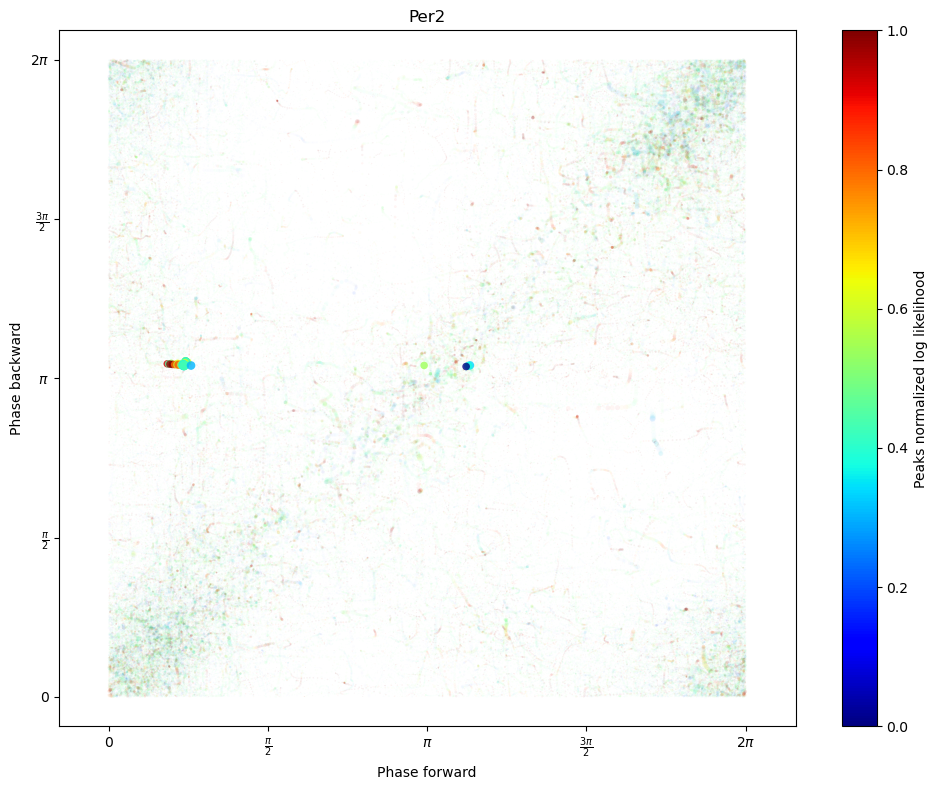

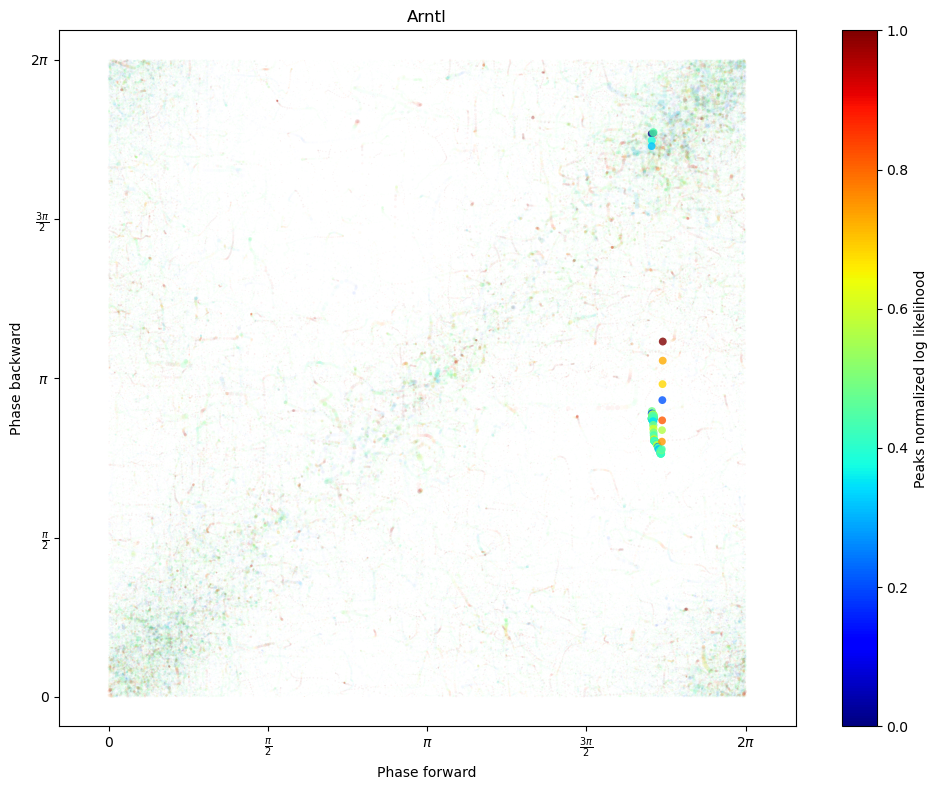

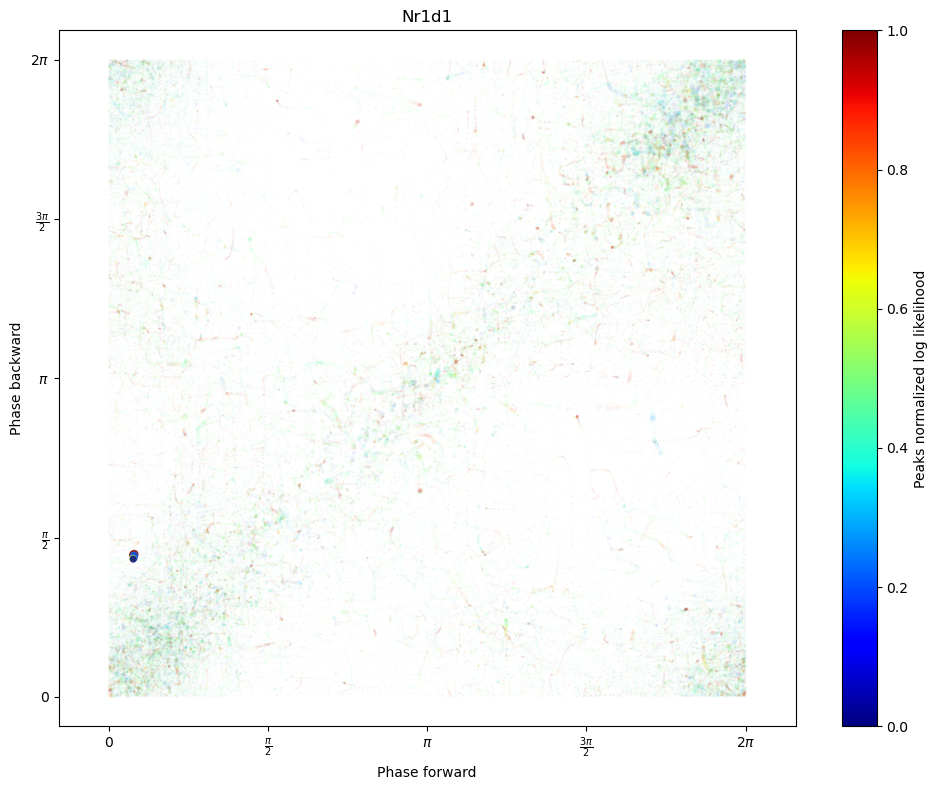

In [9]:

My_Genes = ["Per2","Arntl","Nr1d1"]

genes_idx = np.zeros((kalman_innerjoin.shape[0],len(My_Genes)), dtype=bool)

mean_loc = {}

for g,gene_name in enumerate(My_Genes):

    coords = gene_gtf.loc[(gene_gtf.gene_name == gene_name) & (gene_gtf.feature == "gene"), ['chrom', 'start', 'end']].values
    for coord in coords:
        chrom, start, end = coord
        genes_idx[:,g] = ( (kalman_innerjoin.chr == chrom) & (kalman_innerjoin.start >= start) & (kalman_innerjoin.end <= end) )

        # calculate mean location of the gene
        mean_loc[gene_name] = circstats.circmean(kalman_innerjoin.loc[genes_idx[:,g], ['phi_p', 'phi_m']],0)
    

    df_genes = kalman_innerjoin.loc[genes_idx[:,g],:]
    df_rest = kalman_innerjoin.loc[~genes_idx[:,g],:]


    # plot scatter phase (+ strand) vs phase (- strand)
    fig, ax = plt.subplots(figsize=(10, 8))

    hdl = ax.scatter(df_rest['phi_p'], df_rest['phi_m'], s=df_rest['mean_amp']*10, c=df_rest['mean_norm_LL'], alpha = 0.05*df_rest['mean_norm_LL'], cmap='jet', edgecolors='none')
    fig.colorbar(hdl, ax=ax, label='Peaks normalized log likelihood')
    ax.scatter(df_genes['phi_p'], df_genes['phi_m'], s=df_genes['mean_amp']*20+10, c=df_genes['mean_norm_LL'], alpha = .8, cmap='jet', edgecolors='none')

    ax.set_title(gene_name)
    ax.set_xticks(np.arange(0, 2*np.pi + np.pi/2, np.pi/2))
    ax.set_xticklabels(['0', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$'])
    ax.set_yticks(np.arange(0, 2*np.pi + np.pi/2, np.pi/2))
    ax.set_yticklabels(['0', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$'])
    ax.set_xlabel('Phase forward')
    ax.set_ylabel('Phase backward')
    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(0, 2*np.pi)
    ax.axis('equal')

    fig.tight_layout()
    fig.savefig(f"fig/fig4/kalman_phase_scatter_bin{bin_size}bp_{gene_name}.pdf",dpi=300)

## Correlation function

In [10]:
def cross_correlation(kalman_plus, kalman_minus, dk):
    # shift the phase of the minus strand by dk
    kalman_minus.loc[:,['start', 'end']] += dk
    kalman_innerjoin = pd.merge(kalman_plus, kalman_minus, on=['chr', 'start', 'end'], suffixes=('_p', '_m'))
    return circstats.circcorrcoef(kalman_innerjoin['phi_p'], kalman_innerjoin['phi_m'])

Dk = np.arange(-50, 50, 1, dtype=int)*bin_size
threads = 48
with Pool(processes=threads) as pool:
    OUT = pool.map(partial(cross_correlation, kalman_plus.loc[:,['chr', 'start', 'end','phi']].copy(),  kalman_minus.loc[:,['chr', 'start', 'end','phi']].copy()), Dk)

rho = np.array(OUT)



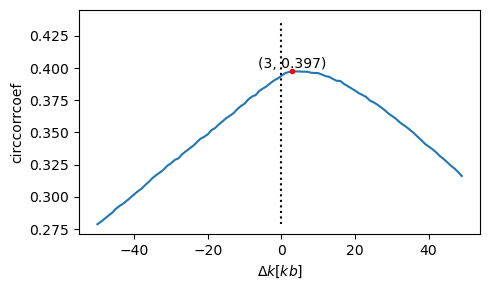

In [11]:

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(Dk/bin_size, rho)
ax.vlines(x=0, ymin=rho.min(), ymax=1.1*rho.max(), color='k', linestyle=':')
idx = np.argmax(rho)
ax.plot(Dk[idx]/bin_size, rho[idx], 'r.', label='Max correlation')
ax.text(Dk[idx]/bin_size, rho[idx], f'({Dk[idx]/bin_size:.0f}, {rho[idx]:.3f})', fontsize=10, ha='center', va='bottom')
ax.set_xlabel(r'$\Delta k [kb]$')
ax.set_ylabel('circcorrcoef')

fig.tight_layout()
fig.savefig(f"fig/fig4/cross_correlation_{bin_size}bp.pdf", bbox_inches='tight')

In [12]:
prop

{'peak_heights': array([0.5179274 , 0.04926399])}